In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/emails.csv')
print(f"📊 Dataset chargé: {len(df)} emails")
print(f"\nDistribution des classes:")
print(df['label'].value_counts())
print(f"\nAperçu des données:")
df.head()

📊 Dataset chargé: 39154 emails

Distribution des classes:
label
1    21842
0    17312
Name: count, dtype: int64

Aperçu des données:


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


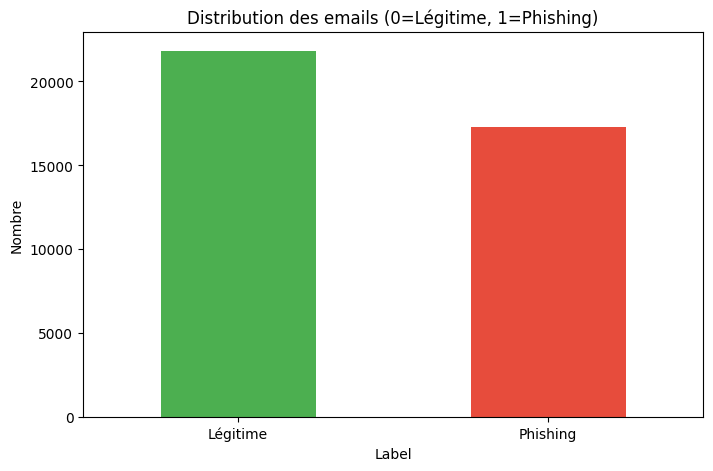

In [4]:
plt.figure(figsize=(8,5))
df['label'].value_counts().plot(kind='bar', color=['#4caf50', '#e74c3c'])
plt.title('Distribution des emails (0=Légitime, 1=Phishing)')
plt.xlabel('Label')
plt.ylabel('Nombre')
plt.xticks([0,1], ['Légitime', 'Phishing'], rotation=0)
plt.show()


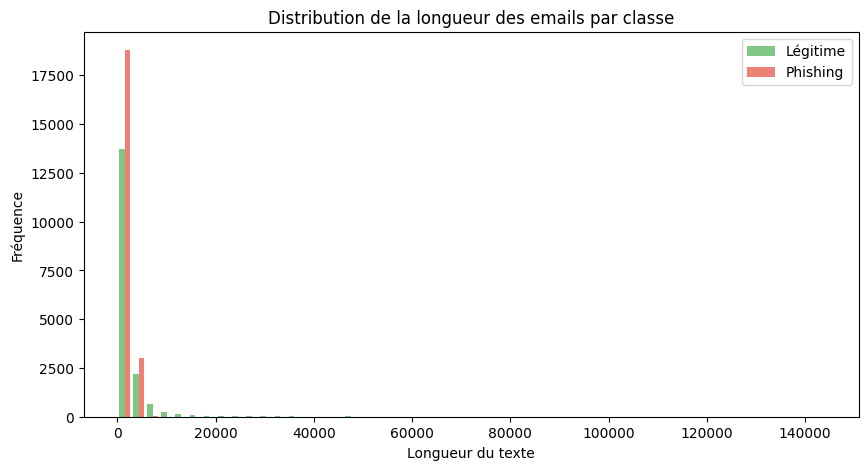

In [5]:
df['text_length'] = df['body'].str.len()

plt.figure(figsize=(10,5))
plt.hist([df[df['label']==0]['text_length'], df[df['label']==1]['text_length']], 
         bins=50, label=['Légitime', 'Phishing'], alpha=0.7, color=['#4caf50', '#e74c3c'])
plt.xlabel('Longueur du texte')
plt.ylabel('Fréquence')
plt.title('Distribution de la longueur des emails par classe')
plt.legend()
plt.show()


In [6]:
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Nettoie le texte"""
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
df['clean_body'] = df['body'].apply(clean_text)
df['clean_subject'] = df['subject'].apply(clean_text)
df['full_text'] = df['clean_subject'] + ' ' + df['clean_body']


In [8]:
def extract_features(text):
    """Extrait des features basiques"""
    features = {}
    features['length'] = len(text)
    features['word_count'] = len(text.split())
    
    suspicious_words = ['urgent', 'verify', 'account', 'password', 'click', 
                        'login', 'security', 'update', 'confirm', 'bank']
    features['suspicious_count'] = sum(1 for word in suspicious_words if word in text)
    
    return features

In [9]:
feature_df = df['full_text'].apply(extract_features).apply(pd.Series)

In [10]:
X = feature_df
y = df['label']

print(f"Features extraites: {X.columns.tolist()}")
X.head()

Features extraites: ['length', 'word_count', 'suspicious_count']


,length,word_count,suspicious_count
0,169,24,0
1,55,7,0
2,1084,167,0
3,7194,1425,2
4,61,2,0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")


Train: 31323 samples
Test: 7831 samples


In [12]:
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=5,
    verbose=50,
    random_seed=42
)

# Entraîner
model.fit(X_train, y_train)


0:	learn: 0.6059806	total: 145ms	remaining: 43.5s
50:	learn: 0.2565653	total: 595ms	remaining: 2.91s
100:	learn: 0.2374088	total: 956ms	remaining: 1.88s
150:	learn: 0.2256895	total: 1.48s	remaining: 1.46s
200:	learn: 0.2178685	total: 1.91s	remaining: 940ms
250:	learn: 0.2129885	total: 2.37s	remaining: 463ms
299:	learn: 0.2095650	total: 2.87s	remaining: 0us


CatBoostClassifier(depth=5, iterations=300, learning_rate=0.1, random_seed=42, verbose=50)

📊 Classification Report:
              precision    recall  f1-score   support

    Légitime       0.93      0.88      0.90      3462
    Phishing       0.91      0.95      0.93      4369

    accuracy                           0.92      7831
   macro avg       0.92      0.91      0.92      7831
weighted avg       0.92      0.92      0.92      7831



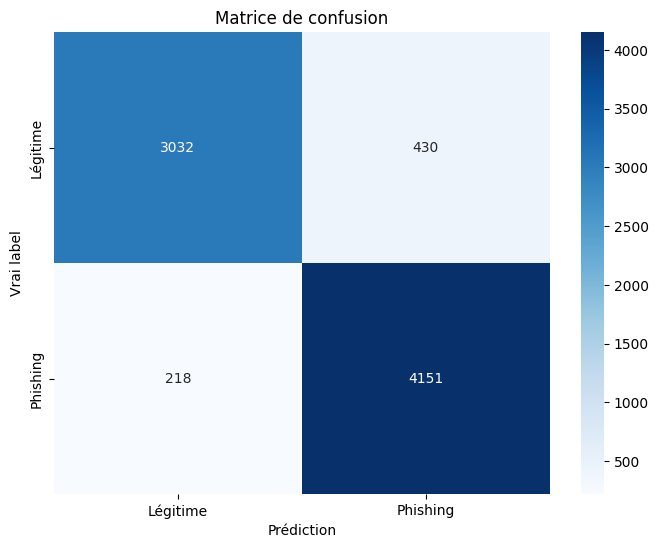

In [13]:
# %%
# Prédictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Métriques
print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Légitime', 'Phishing']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Légitime', 'Phishing'],
            yticklabels=['Légitime', 'Phishing'])
plt.title('Matrice de confusion')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')
plt.show()

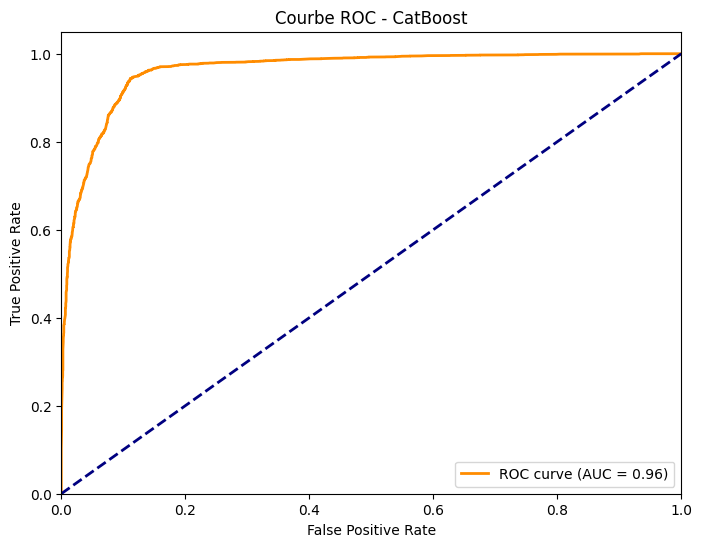

In [14]:
# %% [markdown]
# ### 9. Courbe ROC

# %%
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - CatBoost')
plt.legend(loc="lower right")
plt.show()

In [15]:
# ### 10. Importance des features

# %%
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [16]:
from sklearn.metrics import accuracy_score

# Prédictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train accuracy :", train_acc)
print("Test accuracy  :", test_acc)

# Détection overfitting
if train_acc - test_acc > 0.1:
    print("⚠️ Overfitting détecté !")
else:
    print("✅ Pas d’overfitting majeur")

Train accuracy : 0.9261884238419054
Test accuracy  : 0.9172519473885838
✅ Pas d’overfitting majeur


Dataset: 39154 emails

Distribution:
label
1    21842
0    17312
Name: count, dtype: int64

Proportion phishing: 55.8%


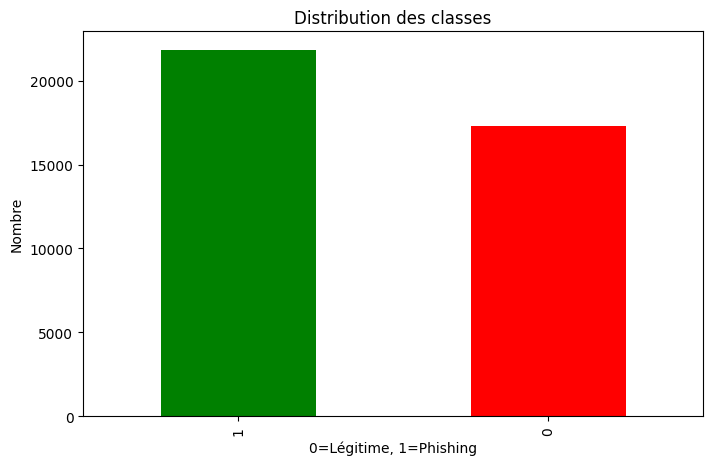

Dataset après ajout: 39654 emails
label
1    21842
0    17812
Name: count, dtype: int64
Features extraites: (39654, 10)
Train - Légitimes: 14250, Phishing: 17473
Test  - Légitimes: 3562, Phishing: 4369
0:	learn: 0.5913981	total: 10.9ms	remaining: 3.25s
50:	learn: 0.1537207	total: 461ms	remaining: 2.25s
100:	learn: 0.1239345	total: 889ms	remaining: 1.75s
150:	learn: 0.1093184	total: 1.47s	remaining: 1.45s
200:	learn: 0.0995557	total: 1.89s	remaining: 933ms
250:	learn: 0.0930000	total: 2.31s	remaining: 451ms
299:	learn: 0.0879596	total: 2.72s	remaining: 0us
RÉSULTATS DU MODÈLE CORRIGÉ

Classification Report:
              precision    recall  f1-score   support

    Légitime       0.96      0.96      0.96      3562
    Phishing       0.97      0.96      0.97      4369

    accuracy                           0.96      7931
   macro avg       0.96      0.96      0.96      7931
weighted avg       0.96      0.96      0.96      7931


Matrice de confusion:
  Vrais Négatifs (légitime correct):

In [17]:
# %% [markdown]
# # 🔧 Correction du modèle - Détection équilibrée

# %% [markdown]
# ## 1. Analyser le déséquilibre

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Charger les données
df = pd.read_csv('../data/emails.csv')
print(f"Dataset: {len(df)} emails")
print(f"\nDistribution:")
print(df['label'].value_counts())
print(f"\nProportion phishing: {df['label'].mean():.1%}")

# Visualiser
plt.figure(figsize=(8,5))
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution des classes')
plt.xlabel('0=Légitime, 1=Phishing')
plt.ylabel('Nombre')
plt.show()

# %% [markdown]
# ## 2. Ajouter des emails légitimes synthétiques

# %%
# Créer des emails légitimes supplémentaires
legitimate_samples = pd.DataFrame({
    'subject': [
        "Weekly team meeting",
        "Project update", 
        "Lunch invitation",
        "Document review",
        "Holiday schedule"
    ] * 100,
    'body': [
        "Join us for the weekly sync at 10am",
        "Here's the latest progress report",
        "Let's have lunch together on Friday",
        "Please review the attached document",
        "Office will be closed on Monday"
    ] * 100,
    'label': [0] * 500
})

# Fusionner avec dataset original
df_augmented = pd.concat([df, legitimate_samples], ignore_index=True)
print(f"Dataset après ajout: {len(df_augmented)} emails")
print(df_augmented['label'].value_counts())

# %% [markdown]
# ## 3. Extraire features équilibrées

# %%
def extract_balanced_features(text):
    """Extraction robuste pour éviter les NaN"""
    if pd.isna(text) or not isinstance(text, str):
        text = ""
    
    text_lower = text.lower()
    
    return {
        'length': min(len(text), 5000),
        'word_count': len(text.split()),
        'has_url': 1 if 'http' in text_lower else 0,
        'has_urgent': 1 if any(w in text_lower for w in ['urgent', 'immediate', 'asap']) else 0,
        'has_verify': 1 if any(w in text_lower for w in ['verify', 'confirm', 'validate']) else 0,
        'has_account': 1 if 'account' in text_lower else 0,
        'has_payment': 1 if any(w in text_lower for w in ['pay', 'payment', 'bank', 'credit card']) else 0,
        'exclamation_count': min(text.count('!'), 5),
        'upper_ratio': sum(1 for c in text if c.isupper()) / max(len(text), 1),
        'word_diversity': len(set(text.split())) / max(len(text.split()), 1)
    }

# Appliquer aux données augmentées
features = df_augmented['subject'] + " " + df_augmented['body']
X = pd.DataFrame([extract_balanced_features(t) for t in features])
y = df_augmented['label']

print(f"Features extraites: {X.shape}")
X.head()

# %% [markdown]
# ## 4. Split avec stratification

# %%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train - Légitimes: {sum(y_train==0)}, Phishing: {sum(y_train==1)}")
print(f"Test  - Légitimes: {sum(y_test==0)}, Phishing: {sum(y_test==1)}")

# %% [markdown]
# ## 5. Entraîner avec pondération

# %%
# Calculer les poids
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)

model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=5,
    verbose=50,
    random_seed=42,
    auto_class_weights='Balanced'  # Auto-équilibrage
)

model.fit(X_train, y_train, sample_weight=sample_weights)

# %% [markdown]
# ## 6. Évaluation complète

# %%
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("="*50)
print("RÉSULTATS DU MODÈLE CORRIGÉ")
print("="*50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Légitime', 'Phishing']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print(f"\nMatrice de confusion:")
print(f"  Vrais Négatifs (légitime correct): {cm[0,0]}")
print(f"  Faux Positifs (phishing détecté à tort): {cm[0,1]}")
print(f"  Faux Négatifs (phishing non détecté): {cm[1,0]}")
print(f"  Vrais Positifs (phishing correct): {cm[1,1]}")

# %% [markdown]
# ## 7. Test sur emails réels

# %%
# Tester sur des emails spécifiques
test_emails = [
    ("Email légitime - Newsletter", "Your weekly newsletter is ready", 0),
    ("Email légitime - Meeting", "Meeting tomorrow at 10am", 0),
    ("Email phishing - URGENT", "URGENT: Your account is suspended! Verify now!", 1),
    ("Email phishing - PayPal", "PayPal: Your account is limited. Click http://bit.ly/verify", 1),
]

print("\n" + "="*50)
print("TESTS SUR EMAILS RÉELS")
print("="*50)

for name, text, expected in test_emails:
    features = extract_balanced_features(text)
    features_df = pd.DataFrame([features])
    proba = model.predict_proba(features_df)[0, 1]
    pred = 1 if proba > 0.6 else 0  # Seuil augmenté à 0.6
    
    status = "✅" if pred == expected else "❌"
    print(f"\n{status} {name}")
    print(f"   Texte: {text[:50]}...")
    print(f"   Probabilité phishing: {proba:.1%}")
    print(f"   Prédiction: {'PHISHING' if pred else 'LÉGITIME'} (attendu: {'PHISHING' if expected else 'LÉGITIME'})")

# %% [markdown]
# ## 8. Sauvegarder le modèle corrigé

# %%
import joblib
joblib.dump(model, '../models/catboost_fixed_model.pkl')
joblib.dump(X.columns.tolist(), '../models/fixed_feature_names.pkl')
print("\n✅ Modèle corrigé sauvegardé!")

In [22]:
# check_dataset.py
import pandas as pd



# Utilisez:
import os
current_dir = os.getcwd()
print(f"Je suis dans: {current_dir}")

# Chemin absolu
file_path = os.path.join(current_dir, 'data', 'emails.csv')
print(f"Chemin complet: {file_path}")

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"✅ Fichier chargé: {len(df)} emails")
else:
    print(f"❌ Fichier non trouvé à: {file_path}")
print(f"Total emails: {len(df)}")
print(f"Légitimes (0): {sum(df['label']==0)}")
print(f"Phishing (1): {sum(df['label']==1)}")
print(f"Proportion phishing: {df['label'].mean():.1%}")

Je suis dans: c:\Users\user\Desktop\Phishing_mail\notebooks
Chemin complet: c:\Users\user\Desktop\Phishing_mail\notebooks\data\emails.csv
❌ Fichier non trouvé à: c:\Users\user\Desktop\Phishing_mail\notebooks\data\emails.csv
Total emails: 39154
Légitimes (0): 17312
Phishing (1): 21842
Proportion phishing: 55.8%
